Spring 2025
<img src="https://www.cuipcairo.org/sites/default/files/styles/medium/public/49658177_2020840098011471_2893445443553853440_n.png?itok=672tzxcF"
 width="80px" align="right">

DSAI 352, Computer Vision

University of Science and Technology, Zewail City

<br>

<h1 align="center">Lab 7</h3>
<h1 align="center">IoU Losses</h3>
<h3 align="center">Non-Max Suppression</h3>

---

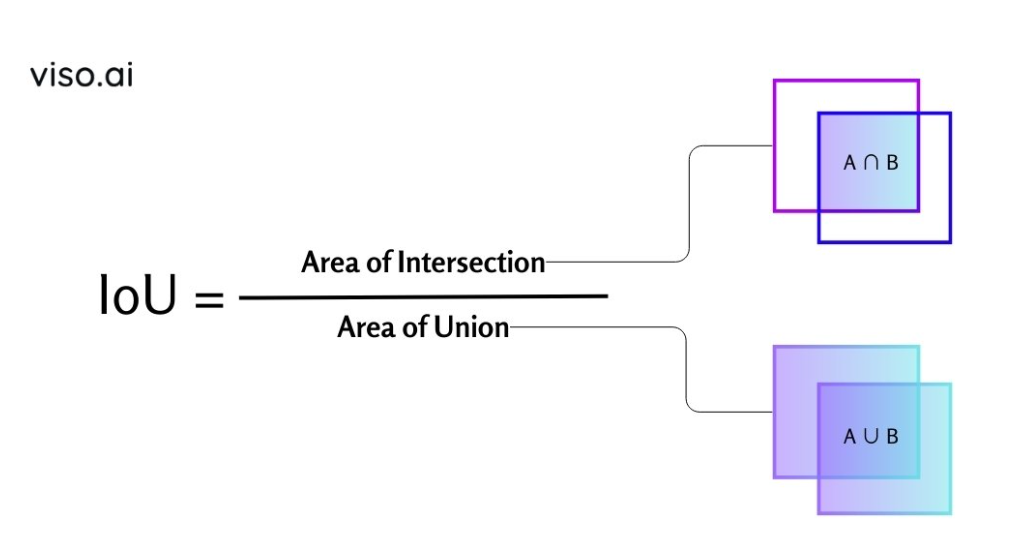

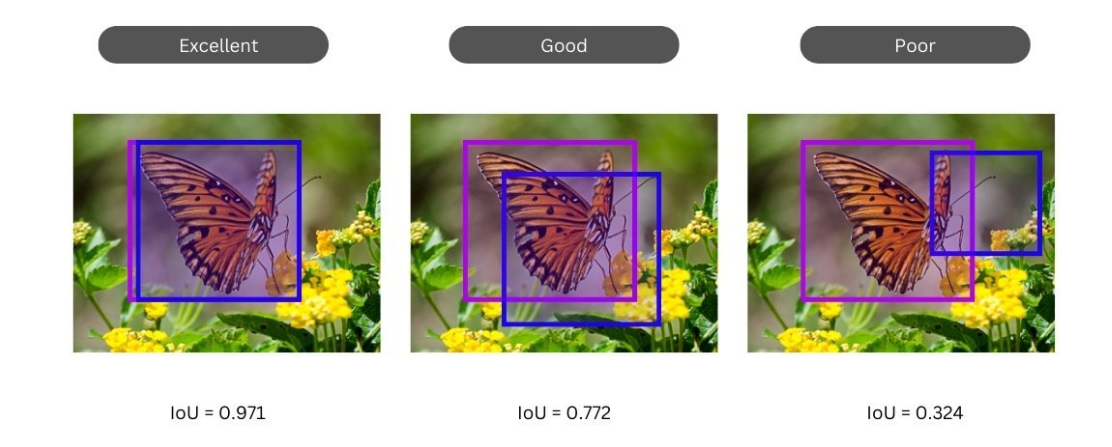

### What is CIFAR-10?
CIFAR-10 is a dataset commonly used for image classification tasks. It consists of **60,000 color images** (32x32 pixels) categorized into **10 classes**:

1. Airplane
2. Automobile
3. Bird
4. Cat
5. Deer
6. Dog
7. Frog
8. Horse
9. Ship
10. Truck

Each class has **6,000 images**, and the dataset is divided into **50,000 training images** and **10,000 test images**.

### What is IoU?
**Intersection over Union (IoU)** is a metric used to measure the overlap

IoU is widely used in object detection tasks to evaluate how well a predicted bounding box aligns with the ground-truth object.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import random

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Define CIFAR-10 class labels
class_labels = ["airplane", "automobile", "bird", "cat", "deer",
                "dog", "frog", "horse", "ship", "truck"]

In [ ]:
# Select a random image
index = random.randint(0, len(x_test) - 1)
image = x_test[index]
label = class_labels[y_test[index][0]]

# Simulate a ground-truth bounding box (within 32x32 range)
gt_box = [6, 6, 20, 20]  # (x, y, width, height)

In [ ]:
# Generate multiple bounding boxes (some correct, some incorrect)
pred_boxes = [
    [5, 5, 19, 19],  # Near ground-truth
    [8, 8, 22, 22],  # Slightly shifted
    [15, 15, 25, 25],  # Incorrect, shifted far
    [3, 3, 28, 28]  # Bigger incorrect box
]

# Colors for different boxes
colors = ['g', 'b', 'r', 'orange']

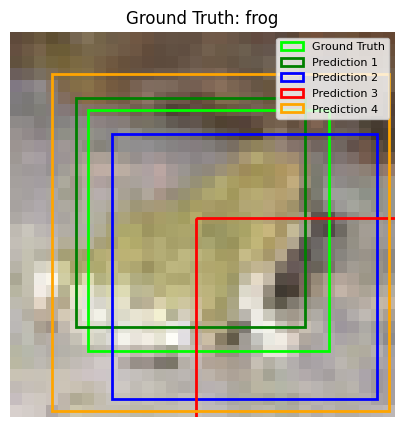

In [ ]:
# Create figure and axis
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(image)
ax.set_title(f"Ground Truth: {label}")

# Draw ground truth box
x, y, w, h = gt_box
ax.add_patch(plt.Rectangle((x, y), w, h, edgecolor='lime', linewidth=2, fill=False, label='Ground Truth'))

# Draw predicted boxes
for i, box in enumerate(pred_boxes):
    x, y, w, h = box
    ax.add_patch(plt.Rectangle((x, y), w, h, edgecolor=colors[i], linewidth=2, fill=False, label=f'Prediction {i+1}'))

ax.legend(loc="upper right", fontsize=8)
ax.axis('off')

plt.show()


### ✅ IoU Calculation:
- Finds the overlapping region between predicted and ground-truth boxes.
- Computes **IoU = Intersection Area / Union Area**.

### ✅ Loss Function:
- **Loss = 1 - IoU** (Higher IoU = Lower Loss).
- If no overlap, **IoU = 0**, so **Loss = 1**.


In [ ]:
# Function to compute IoU
def compute_iou(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    # Compute coordinates of intersection box
    x_left = max(x1, x2)
    y_top = max(y1, y2)
    x_right = min(x1 + w1, x2 + w2)
    y_bottom = min(y1 + h1, y2 + h2)

    if x_right < x_left or y_bottom < y_top:
        return 0.0  # No overlap

    # Compute areas
    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    box1_area = w1 * h1
    box2_area = w2 * h2
    union_area = box1_area + box2_area - intersection_area

    return intersection_area / union_area if union_area > 0 else 0.0

# Compute IoU and loss for each prediction
iou_scores = [compute_iou(gt_box, box) for box in pred_boxes]
losses = [1 - iou for iou in iou_scores]


In [ ]:
losses

[0.25858123569794045,
 0.4214285714285714,
 0.8661504424778761,
 0.4897959183673469]

## ✅ Bounding Box Loss Computation using IoU and GIoU

### Overview
To compute the loss between the ground-truth bounding box and predicted boxes, we use **Intersection over Union (IoU)** and **Generalized IoU (GIoU)** as metrics. A common loss function in object detection is:



For more robust evaluation, we also use **Generalized IoU (GIoU)**:

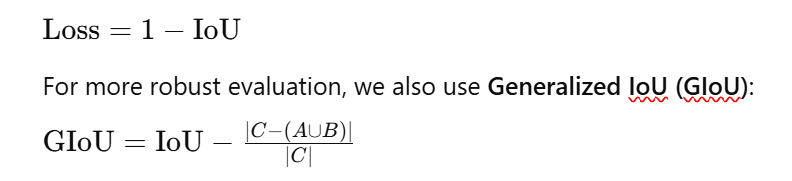

where:

- \( C \) is the smallest enclosing box containing both ground-truth and predicted boxes.
- \( A \) and \( B \) are the respective areas of the two boxes.

This helps when predictions have no overlap with the ground-truth box.

### Steps:
1. Compute **IoU** between each predicted box and the ground-truth box.
2. Compute **GIoU** for each predicted box.
3. Use **1 - GIoU** as the loss.



In [ ]:
# Function to compute IoU
def compute_iou(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    # Compute coordinates of intersection box
    x_left = max(x1, x2)
    y_top = max(y1, y2)
    x_right = min(x1 + w1, x2 + w2)
    y_bottom = min(y1 + h1, y2 + h2)

    if x_right < x_left or y_bottom < y_top:
        return 0.0  # No overlap

    # Compute areas
    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    box1_area = w1 * h1
    box2_area = w2 * h2
    union_area = box1_area + box2_area - intersection_area

    return intersection_area / union_area if union_area > 0 else 0.0

In [ ]:
def compute_giou(box1, box2):
    iou = compute_iou(box1, box2)

    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    # Compute smallest enclosing box
    x_enclose_left = min(x1, x2)
    y_enclose_top = min(y1, y2)
    x_enclose_right = max(x1 + w1, x2 + w2)
    y_enclose_bottom = max(y1 + h1, y2 + h2)

    enclosing_area = (x_enclose_right - x_enclose_left) * (y_enclose_bottom - y_enclose_top)

    # Compute intersection area
    intersection = iou * (w1 * h1 + w2 * h2) / (1 + iou)  # Derived from IoU formula
    """
    I/U * (w1 * h1 + w2 * h2) / 1 + I/U
    Hint to understand: Multiply the right hand side with Union
    I * (w1 * h1 + w2 * h2) / U+I
    since (w1 * h1 + w2 * h2) = U + I
    therfore final value is the intersection
    """
    # Compute union area
    union_area = w1 * h1 + w2 * h2 - intersection

    # Compute GIoU
    giou = iou - (enclosing_area - union_area) / enclosing_area
    return giou


In [ ]:
# Compute IoU, GIoU, and loss for each prediction
iou_scores = [compute_iou(gt_box, box) for box in pred_boxes]
giou_scores = [compute_giou(gt_box, box) for box in pred_boxes]
losses = [1 - giou for giou in giou_scores]

In [ ]:
losses

[0.8123673573166873,
 0.7746527777777779,
 1.0981537266129773,
 0.7501041232819659]

## ✅ Bounding Box Loss Computation using DIoU

### Overview
To compute the loss between the ground-truth bounding box and predicted boxes, we use **Distance IoU (DIoU)** as a metric.

A common loss function in object detection is:

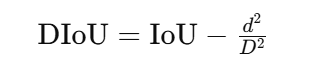

where:

- \( d \) is the Euclidean distance between the centers of the two boxes.
- \( c \) is the diagonal length of the smallest enclosing box.

DIoU helps when predictions have poor localization by penalizing distance between centers.

### Steps:
1. Compute **IoU** between each predicted box and the ground-truth box.
2. Compute **DIoU** for each predicted box.
3. Use **1 - DIoU** as the loss.


In [ ]:
# Function to compute DIoU
def compute_diou(box1, box2):
    iou = compute_iou(box1, box2)
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    center1 = (x1 + w1 / 2, y1 + h1 / 2)
    center2 = (x2 + w2 / 2, y2 + h2 / 2)
    d = np.linalg.norm(np.array(center1) - np.array(center2))

    x_enclose_left = min(x1, x2)
    y_enclose_top = min(y1, y2)
    x_enclose_right = max(x1 + w1, x2 + w2)
    y_enclose_bottom = max(y1 + h1, y2 + h2)
    D = np.linalg.norm(np.array([x_enclose_right, y_enclose_bottom]) - np.array([x_enclose_left, y_enclose_top]))

    return iou - (d**2 / D**2)

# Compute IoU, GIoU, DIoU, and loss
iou_scores = [compute_iou(gt_box, box) for box in pred_boxes]
giou_scores = [compute_giou(gt_box, box) for box in pred_boxes]
diou_scores = [compute_diou(gt_box, box) for box in pred_boxes]
losses = [1 - diou for diou in diou_scores]


In [ ]:
print(" Distance IoU (DIoU):", losses )

 Distance IoU (DIoU): [0.26368327651426693, 0.4370535714285714, 0.9805535566647273, 0.4910714285714286]


In [ ]:
for i, loss in enumerate(losses):
    print(f"Prediction {i+1} - IoU: {iou_scores[i]:.2f}, GIoU: {giou_scores[i]:.2f}, DIoU: {diou_scores[i]:.2f}, Loss: {loss:.2f}")
    if loss > 0.5:
        print(f"Warning: Prediction {i+1} has a high loss, indicating a poor bounding box.")

Prediction 1 - IoU: 0.74, GIoU: 0.19, DIoU: 0.74, Loss: 0.26
Prediction 2 - IoU: 0.58, GIoU: 0.23, DIoU: 0.56, Loss: 0.44
Prediction 3 - IoU: 0.13, GIoU: -0.10, DIoU: 0.02, Loss: 0.98
Prediction 4 - IoU: 0.51, GIoU: 0.25, DIoU: 0.51, Loss: 0.49


## ✅Non-Maximum Suppression (NMS) Algorithm
**Non-Maximum Suppression (NMS)** is used to remove redundant or overlapping bounding boxes, keeping only the most confident predictions. The steps are:

1. Sort all predicted boxes by their confidence scores.
2. Select the box with the highest confidence.
3. Compute **IoU** between this box and all other remaining boxes.
4. Remove boxes with **IoU above a certain threshold** (e.g., 0.5) to suppress redundant detections.
5. Repeat until no more boxes remain.

In [ ]:
# Function to perform Non-Maximum Suppression (NMS)
def non_max_suppression(boxes, scores, iou_threshold=0.5):
    indices = np.argsort(scores)[::-1]  # Sort by confidence score descending
    selected_boxes = []

    while len(indices) > 0:
        best_index = indices[0]
        selected_boxes.append(boxes[best_index])

        remaining_indices = indices[1:]
        filtered_indices = []

        for i in remaining_indices:
            if compute_iou(boxes[best_index], boxes[i]) < iou_threshold:
                filtered_indices.append(i)

        indices = np.array(filtered_indices)

    return selected_boxes

# Example confidence scores
scores = [0.9, 0.85, 0.6]
selected_boxes = non_max_suppression(pred_boxes, scores)
print("Selected boxes after NMS:", selected_boxes)

Selected boxes after NMS: [[5, 5, 19, 19], [8, 8, 22, 22], [15, 15, 25, 25]]


# Extra Example

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Image Shape: (459, 630, 3)


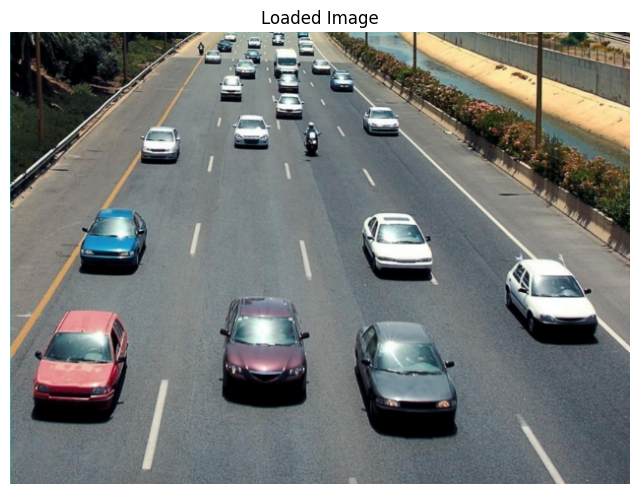

In [ ]:
# Load the image
image_path = "/content/drive/MyDrive/TA/Computer Vision/Lab 7/Sample.png"
image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB for display

# Print image shape
print("Image Shape:", image.shape)

# Display the image
plt.figure(figsize=(8, 6))
plt.imshow(image)
plt.axis("off")  # Hide axes
plt.title("Loaded Image")
plt.show()

In [ ]:
import cv2
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd

# Function to compute IoU
def compute_iou(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    # Compute coordinates of intersection box
    x_left = max(x1, x2)
    y_top = max(y1, y2)
    x_right = min(x1 + w1, x2 + w2)
    y_bottom = min(y1 + h1, y2 + h2)

    if x_right < x_left or y_bottom < y_top:
        return 0.0  # No overlap

    # Compute areas
    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    box1_area = w1 * h1
    box2_area = w2 * h2
    union_area = box1_area + box2_area - intersection_area

    return intersection_area / union_area if union_area > 0 else 0.0

# Function to visualize bounding boxes
def visualize_boxes(image, boxes, title="Visualization"):
    image_copy = image.copy()

    for (x, y, w, h) in boxes:
        cv2.rectangle(image_copy, (x, y), (x + w, y + h), (255, 140, 0), 2)

    plt.figure(figsize=(10, 6))
    plt.imshow(image_copy)
    plt.axis("off")
    plt.title(title)
    plt.show()

# Function to perform Non-Maximum Suppression (NMS)
def non_max_suppression(boxes, scores, iou_threshold=0.5):
    indices = np.argsort(scores)[::-1]  # Sort by confidence score descending
    selected_boxes = []

    while len(indices) > 0:
        filtered = []
        best_index = indices[0]
        selected_boxes.append(boxes[best_index])

        remaining_indices = indices[1:]
        filtered_indices = []

        for i in remaining_indices:
            if compute_iou(boxes[best_index], boxes[i]) < iou_threshold:
                filtered_indices.append(i)
                filtered.append(boxes[i])

        indices = np.array(filtered_indices)
        # Visualize intermediate steps
        visualize_boxes(image, selected_boxes + filtered, title="NMS Iteration")

    return selected_boxes


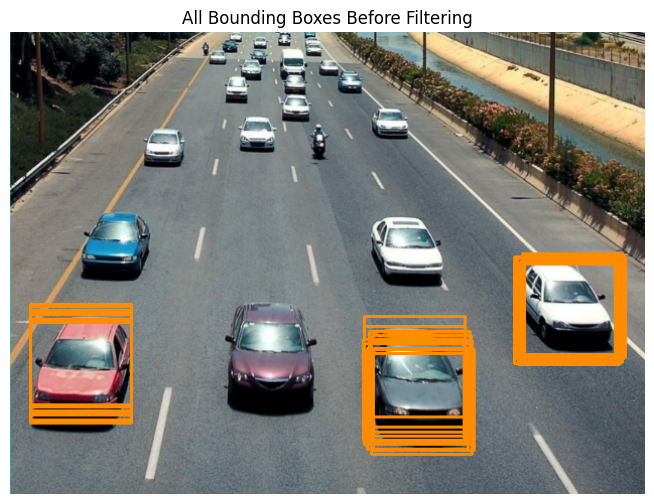

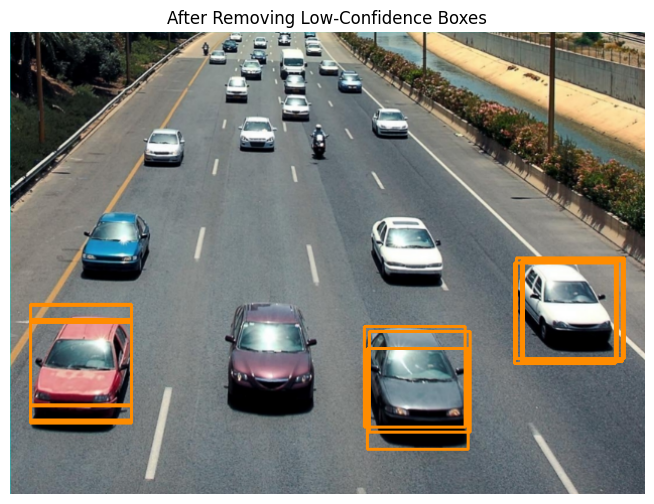

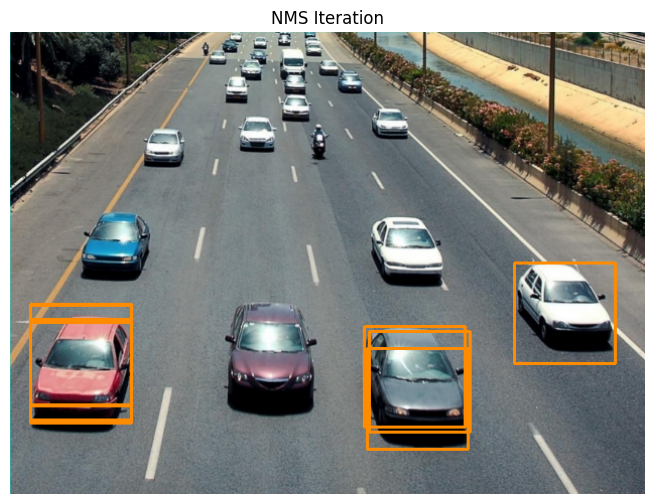

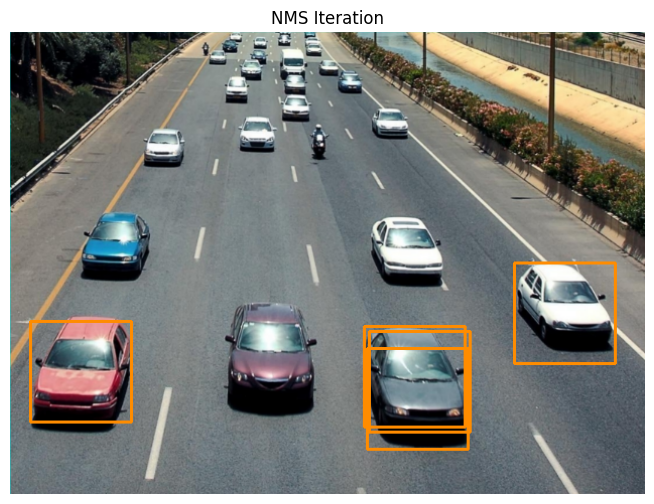

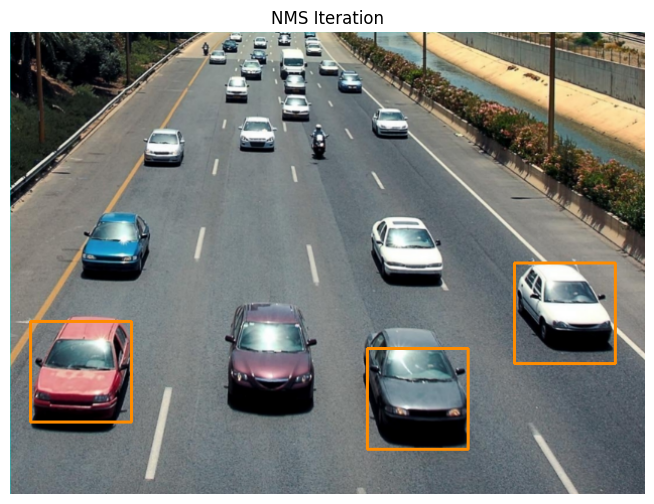

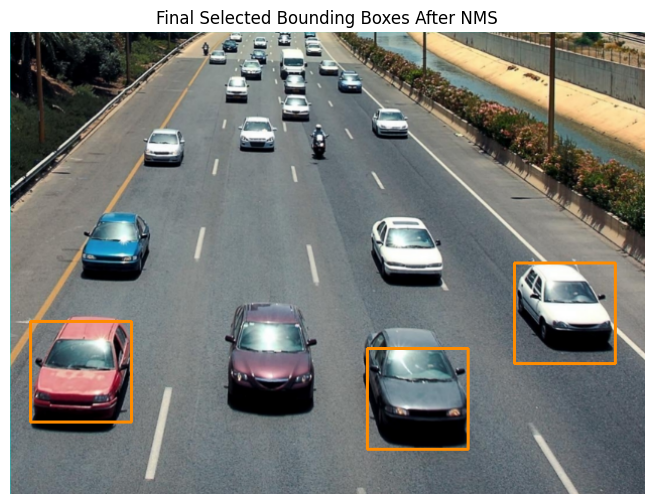

In [ ]:
# Define fixed window size
window_size = (100, 100)  # Constant window size (width, height)
num_windows_per_car = 12  # Number of sliding windows per car

# Define bounding boxes for cars
car_bboxes = [
    (20, 270, 100, 120),  # Car 1 (leftmost car)
    (350, 280, 110, 140),  # Car 2 (middle car)
    (500, 220, 110, 110)   # Car 3 (rightmost car)
]

# Store window details
window_data = []

# Generate randomized sliding windows for each car
for (x_start, y_start, w, h) in car_bboxes:
    for _ in range(num_windows_per_car):  # Fixed number of windows per car
        # Choose a random top-left position within the bounding box
        x = random.randint(x_start, x_start + w - window_size[0])
        y = random.randint(y_start, y_start + h - window_size[1])

        # Generate a random confidence score (0 to 1)
        score = round(random.uniform(0, 1), 2)

        # Store window data (score, x, y, width, height)
        window_data.append((score, x, y, window_size[0], window_size[1]))

# Convert window data to DataFrame
df = pd.DataFrame(window_data, columns=["Score", "X", "Y", "Width", "Height"])

# Step 1: Visualize all bounding boxes before filtering
pred_boxes = [(x, y, w, h) for _, x, y, w, h in window_data]
visualize_boxes(image, pred_boxes, title="All Bounding Boxes Before Filtering")

# Step 2: Remove boxes with a score < 0.6
filtered_data = [entry for entry in window_data if entry[0] >= 0.6]
filtered_boxes = [(x, y, w, h) for _, x, y, w, h in filtered_data]
scores = [s for s, _, _, _, _ in filtered_data]

# Visualize after filtering low-score boxes
visualize_boxes(image, filtered_boxes, title="After Removing Low-Confidence Boxes")

# Step 3: Apply NMS iteratively and visualize after each iteration
selected_boxes = non_max_suppression(filtered_boxes, scores, iou_threshold=0.5)

# Final visualization after NMS completes
visualize_boxes(image, selected_boxes, title="Final Selected Bounding Boxes After NMS")
